In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
voltagedata = pd.read_csv('./output/stationTest.CSV')
voltagedata['voltage'] = voltagedata['sensor'] * (5 / 16383)

clickerdata = pd.read_csv('./csvs/platform_run.csv')

window_half_width = 50
use_exact_match = False
max_time_diff = 1

voltagedata['seconds'] = pd.to_numeric(voltagedata['seconds'], errors='coerce')
clickerdata['seconds'] = pd.to_numeric(clickerdata['seconds'], errors='coerce')

In [86]:
#drop rowss
voltagedropped = voltagedata.dropna(subset=['seconds']).reset_index(drop=True)
clickerdropped = clickerdata.dropna(subset=['seconds']).reset_index(drop=True)

In [87]:
print(type(voltagetimes))

<class 'numpy.ndarray'>


In [88]:
# shift both files so first event starts at 0
t0_voltage = voltagedropped['seconds'].iloc[0]
t0_clicker = clickerdropped['seconds'].iloc[0]

voltagedropped['seconds'] = voltagedropped['seconds'] - t0_voltage
clickerdropped['seconds'] = clickerdropped['seconds'] - t0_clicker

# convert to numpy arrays
voltagetimes = voltagedropped['seconds'].to_numpy()
clickertimes = clickerdropped['seconds'].to_numpy()

print(f"voltage csv first time was {t0_voltage}, now starts at {voltagetimes[0]}")
print(f"clicker csv first time was {t0_clicker}, now starts at {clickertimes[0]}")

voltage csv first time was 81750.0, now starts at 0.0
clicker csv first time was 2573.8, now starts at 0.0


In [91]:
#find indices that are in both csvs
matching = []
if use_exact_match:
    precision = 3
    timeindices = {}

    for i, t in enumerate(voltagetimes):
        t_round = round(t, precision)
        timeindices.setdefault(t_round, []).append(i)

    for t in clickertimes:
        t_round = round(t, precision)
        if t_round in timeindices:
            matching.extend(timeindices[t_round])

else:
    for t in clickertimes:
        index = np.argmin(np.abs(voltagetimes - t))
        diff = abs(voltagetimes[index] - t)

        if diff <= max_time_diff:
            matching.append(index)

# remove duplicates + sort
matching = sorted(set(matching))

print(f'Number of events that occur at the same time in both csvs: {len(matching)}')
print(f'Matched Indices: {matching}')

Number of events that occur at the same time in both csvs: 16
Matched Indices: [np.int64(0), np.int64(108), np.int64(633), np.int64(1052), np.int64(1194), np.int64(1731), np.int64(2039), np.int64(4003), np.int64(5107), np.int64(5197), np.int64(5643), np.int64(6886), np.int64(9374), np.int64(9645), np.int64(9769), np.int64(10144)]


In [92]:
#build windows around each event.for now the windows include 50 events around each second that we have identifies an event
windows = []
indexranges = []

for index in matching:
    startindex = max(0, index - window_half_width)
    endindex = min(len(voltagedropped) - 1, index + window_half_width)

    windowdf = voltagedropped.iloc[startindex:endindex + 1].copy().reset_index(drop=True)
    windows.append(windowdf)
    indexranges.append((startindex, endindex))

print(f'Created {len(windows)} windows.')

Created 16 windows.


In [94]:
windowArr = [w.to_numpy() for w in windows]
#windowArr[0]

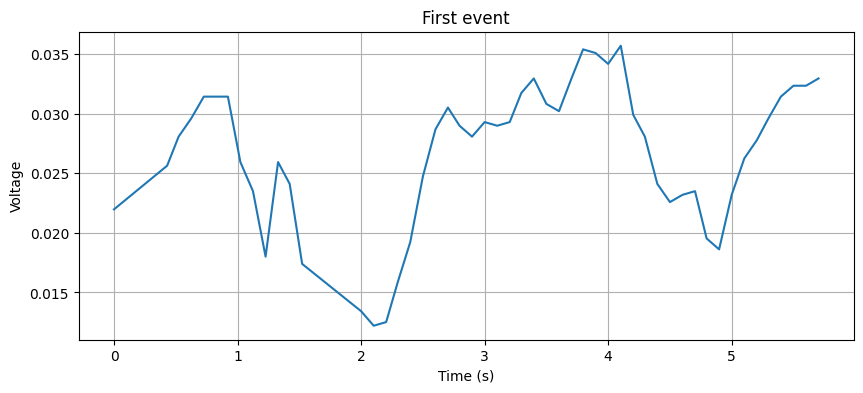

In [97]:
w = windows[0]

plt.figure(figsize=(10,4))
plt.plot(w['seconds'], w['voltage'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('First event')
plt.grid(True)
plt.show()